In [21]:
import numpy as np
import sys
sys.path.append('..')
import os
import torch
from torch.utils.data import TensorDataset, DataLoader
from pytorch_lightning.loggers import TensorBoardLogger
import warnings
import pickle
import json
from mpl_toolkits.axes_grid1 import make_axes_locatable
warnings.filterwarnings("ignore")
from collections import OrderedDict
import pickle
import xarray as xr
import geopandas as gpd
from geojson import Point, Feature, FeatureCollection, dump

from src.data_assemble.assemble_ml import *
from src.data_assemble.assemble_conv import *
from src.models.utils import *
from src.data_utils.data_processing import *
from src.data_assemble.wrap_data import *
from src.models.WindCNN import *
from src.data_assemble.wrap_data import *
torch.manual_seed(112)
random.seed(112)

# Preparing input data for NN (reading from tif from prescribed region and timeframe)

In [8]:
path_to_files = '../data/CMIP/*.nc'
half_side_size = 3
rectangle_coords = {'lat_min': 39.38, 'lat_max': 55.52,'lon_min': 30.12, 'lon_max': 49.45}
target_res = {'lon_res': 0.25, 'lat_res': 0.25}
filter_dict = {"years": ['2006', '2016'], "bands": ['Wind_', 'pr_', 'tasmax', 'tasmin']}
time_limits = {'t_start': np.datetime64('2022-05-11'), 't_end': np.datetime64('2022-14-11')}

blocks = make_blocks([path_to_files], filter_dict, rectangle_coords, target_res, half_side_size=half_side_size, time_limits=time_limits)

100%|██████████| 4/4 [00:03<00:00,  1.22it/s]


In [9]:
X = assemble_numpy_ds(blocks=blocks, target='', stations_pixs='', include_target=False)

# Initializing NN alongside with DataModule (to get data transform)

In [13]:
#initialize and load model

batch_size = 1024
with open(os.path.join('..', 'conf', 'conv_config.json')) as fs:
    args = json.load(fs)

path_to_training_data = os.path.join('..', 'data', 'nn_train')
st_split_dict = train_val_test_split(path_to_training_data, train = 0.5, val = 0.25, test = 0.25, verbose = True)

X_init, y_init = extract_splitted_data(path_to_training_data, st_split_dict)

{'Train': ['Валуйки', 'Цимлянск(Волгодонск)', 'Туапсе', 'Гигант', 'Богородицкое-Фенино', 'Приморско-Ахтарск', 'Готня'], 'Val': ['Красная Поляна', 'Краснодар, Круглик', 'Армавир'], 'Test': ['Чертково', 'Ремонтное', 'Таганрог', 'Анапа', 'Сочи']}


In [15]:
logger = TensorBoardLogger(save_dir='../logs/wind', name='windnet')

dm = WindDataModule(X=X_init, y=y_init, batch_size=batch_size, downsample=False)
model = WindNetPL(args)

chk_path = "lightning_logs/version_12"
chk_path = os.path.join(chk_path, "checkpoints", os.listdir(os.path.join(chk_path, "checkpoints"))[0])
model2 = WindNetPL.load_from_checkpoint(chk_path, args=args)
model2.eval()

WindNetPL(
  (net): WindNet(
    (conv1): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (conv2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
    (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc): Linear(in_features=800, out_features=2, bias=True)
    (net): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
      (1): ReLU()
      (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
      (3): ReLU()
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Flatten(start_dim=1, end_dim=-1)
      (6): Linear(in_features=800, out_features=2, bias=True)
      (7): LogSoftmax(dim=None)
    )
  )
  (accuracy): Accuracy()
  (AUROC): AUROC()
  (precision_m): Precision()
  (recall): Recall()
  (F1): F1Score()
  (conf_matrix): ConfusionMatrix()
  (stats_scores): Stat

# Preparing space xarray placeholder to save NN inference

In [16]:
lat_axis = []
lon_axis = []
for pix_idx, curr_X in X.items():
    curr_lat = curr_X.lat[half_side_size-1].data
    lat_axis.append(curr_lat)
    curr_lon = curr_X.lon[half_side_size-1].data
    lon_axis.append(curr_lon)
time_axis = curr_X.time.data
lat_axis = np.sort(np.unique(np.array(lat_axis)))
lon_axis = np.sort(np.unique(np.array(lon_axis)))
inference_xarray = xr.DataArray.from_dict({"coords": 
                                                {
                                                "lon":  {"dims": "lon", "data": lon_axis},
                                                "lat":  {"dims": "lat", "data": lat_axis}, 
                                                "time": {"dims": "time", "data": time_axis}
                                                },

                                           "data": np.ones((len(lon_axis), len(lat_axis), len(time_axis))),
                                           "attrs": curr_X.attrs})

# Dumping output probabilities to xarray

In [17]:
for pix_idx, curr_X in tqdm(X.items()):
    curr_lat  = curr_X.lat[half_side_size-1].data
    curr_lon  = curr_X.lon[half_side_size-1].data
    with torch.no_grad():
        inference_pix = model(dm.transform(torch.tensor(curr_X.data, device=model.device).double())).exp()[:,1].cpu().numpy()
    inference_xarray.loc[dict(lat=curr_lat, lon=curr_lon)] = inference_pix
inference_xarray.name = 'prob'

100%|██████████| 4884/4884 [00:54<00:00, 89.55it/s]


# Convert xarray to geopandas

In [101]:
tmp = inference_xarray.to_dataframe().reset_index()

In [102]:
gdf = gpd.GeoDataFrame(
    tmp.prob, geometry=gpd.points_from_xy(tmp.lon,tmp.lat), crs="EPSG:4326")
gdf['time'] = tmp.time    

# Save result into geojson

In [104]:
# json_gdf = gdf.to_json()
path_to_nn_infer = "/home/s.lukashevich/Wind/data/nn_inference"
inf_file_name = 'month_nov_2022.geojson'
# with open(os.path.join(path_to_nn_infer, inf_file_name), 'w') as f:
#    dump(json_gdf, f)
gdf.to_file(os.path.join(path_to_nn_infer, inf_file_name), driver="GeoJSON")  
# gdf_ = gpd.read_file(open(os.path.join(path_to_nn_infer, inf_file_name)))

# Visualization

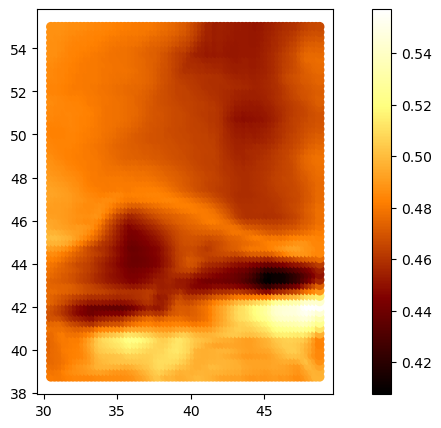

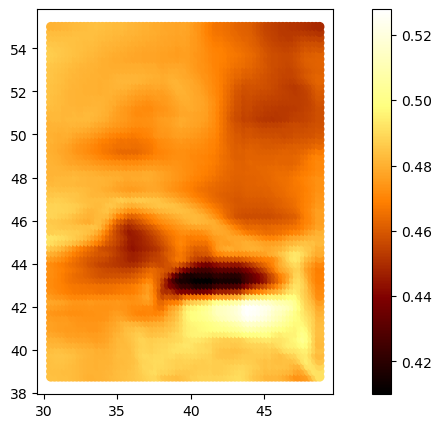

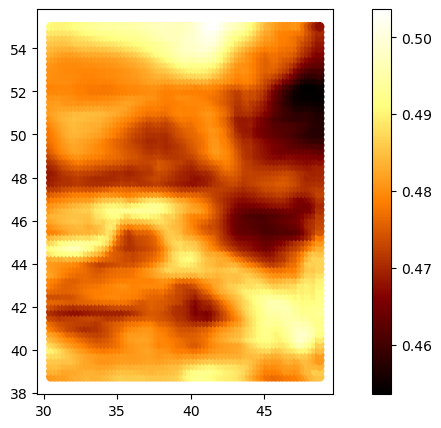

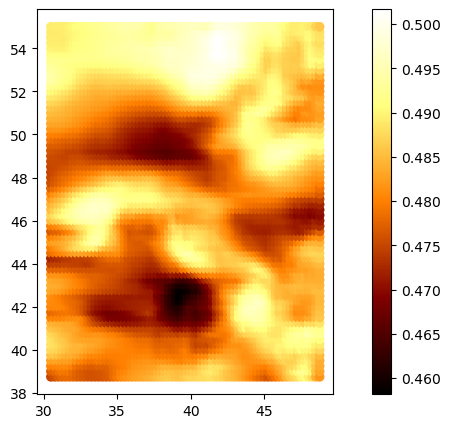

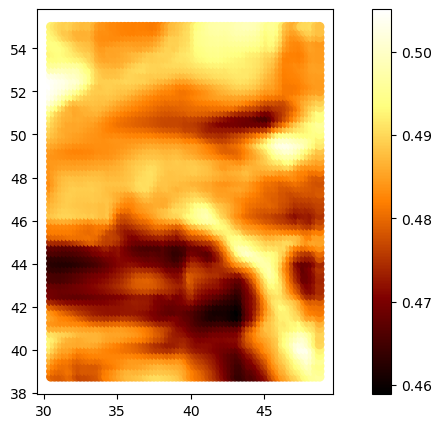

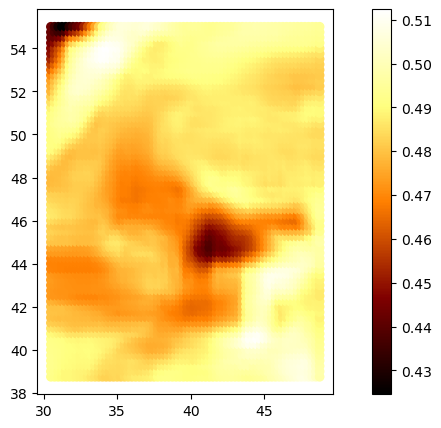

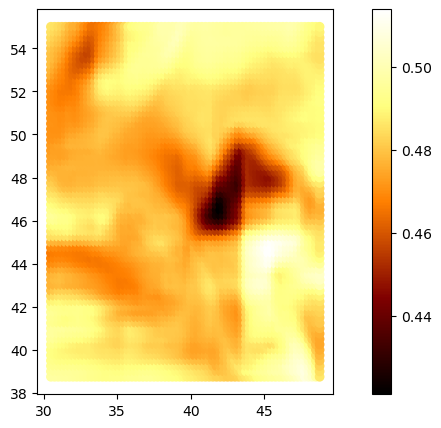

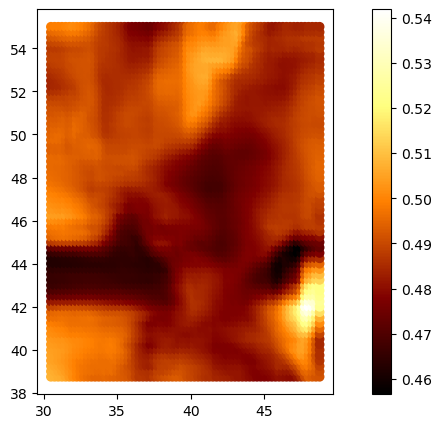

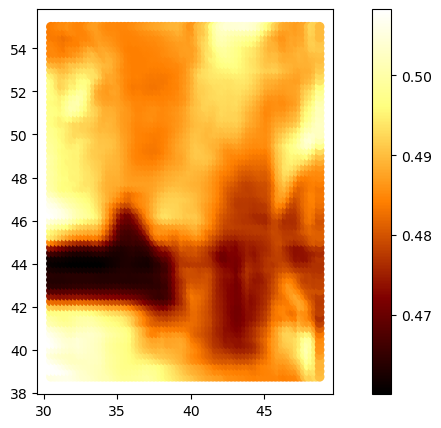

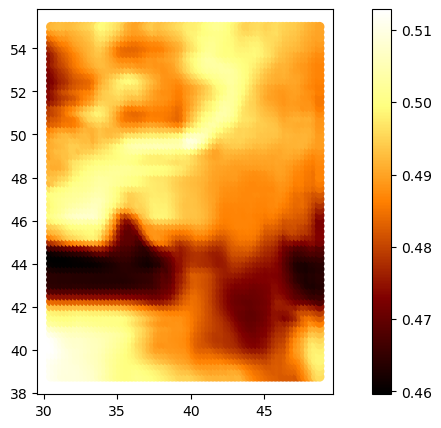

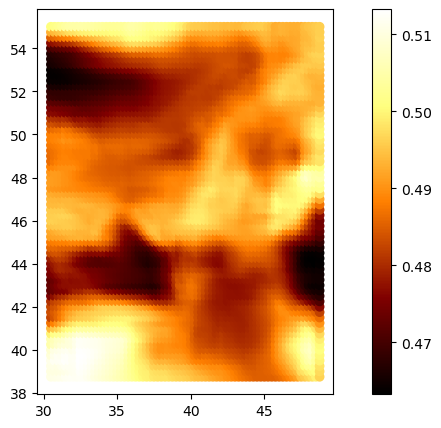

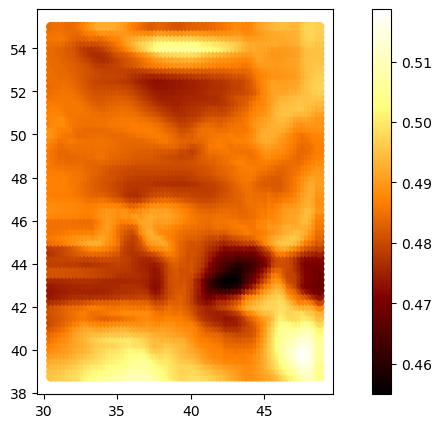

In [98]:
for i, time in enumerate(gdf.time.unique()):
    f, ax = plt.subplots(1, figsize=(10, 5))
    ax = gdf[gdf['time'] == time].plot(column='prob', cmap='afmhot', ax=ax, legend=True)
    if i > 10:
        break
    plt.show()